# FSSK Signature Kernel

This notebook validates and benchmarks `FSSKSigKernel`, the signature kernel induced by a *finite state-space kernel* (FSSK)

$$K_{A,b}^\Lambda(t,s) = \sum_{r=1}^q \bigl(\mathbf{1}^\top e^{-\Lambda(t-s)} b_r\bigr) A_r$$

**Contents**

| Section | What it shows |
|---|---|
| Shared data | Random and deterministic test paths |
| Validation: λ=0 | FSSK with a scalar zero decay matrix recovers the classical signature kernel |
| `from_prony` | Constructing an FSSK from Prony-series parameters; single-pair kernel and full solution grid |
| `from_matrix` | 2×2 non-diagonal decay; batchwise Gram matrix |
| `from_jordan` | Oscillatory Jordan parameterisation of the same kernel; numerical agreement with `from_matrix` |
| Convergence study | Dyadic Richardson extrapolation comparing `etd1` (order 1) vs `heun` (order 2) schemes |

In [1]:
import os
os.environ.setdefault(
    "XLA_FLAGS",
    f"--xla_force_host_platform_device_count={os.cpu_count()}",
)

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from tensordev.sss.kernel import FSSK
from tensordev.kernel.fssk import FSSKSigKernel, fssk_sigkernel
from tensordev.kernel.sig import SigKernel
from tensordev.util.random_paths import (
    random_trigonometric_polynomial_paths, perturb_path_batch,
    deterministic_trigonometric_path_pair,
)

## Shared data

In [2]:
dtype = jnp.float64
d = 20

# Random paths — used for quick validation
key_x = jax.random.PRNGKey(8998)
key_y = jax.random.PRNGKey(898098)
n = 25
t = jnp.linspace(0.0, 1.0, n)
dt = float(t[1] - t[0])

X = random_trigonometric_polynomial_paths(key_x, batch=64, steps=n, dim=d, horizon=1.0)
Y = random_trigonometric_polynomial_paths(key_y, batch=64, steps=n, dim=d, horizon=1.0)
print("X:", X.shape, "  Y:", Y.shape, "  dt:", dt)

X: (64, 26, 20)   Y: (64, 26, 20)   dt: 0.041666666666666664


## Deterministic paths

Fixed 100-step trigonometric paths used as base signals throughout the main experiments.

In [3]:
N = 100
s_grid = jnp.linspace(0.0, 1.0, N + 1, dtype=dtype)
t_grid = jnp.linspace(0.0, 1.0, N + 1, dtype=dtype)
dt_s = float(s_grid[1] - s_grid[0])
dt_t = float(t_grid[1] - t_grid[0])

x, w = deterministic_trigonometric_path_pair(s_grid, d)
print("x:", x.shape, "  w:", w.shape)

x: (101, 20)   w: (101, 20)


## Validation: lambda=0 recovers the classical signature kernel

With a scalar zero decay rate and identity projection `A = I_d`, the FSSK kernel reduces to the classical truncated signature kernel.

In [4]:
ker_identity = FSSK.from_matrix(
    Lambda=jnp.array([[0.0]], dtype=dtype),
    A=jnp.eye(d, dtype=dtype)[None],
    b=jnp.array([[1.0]], dtype=dtype),
)

sigker_fssk      = FSSKSigKernel(kernel=ker_identity, dt_x=dt, dt_y=dt, scheme='heun')
sigker_classical = SigKernel(dyadic_order=0)

k_fssk      = sigker_fssk.compute_kernel(X[:4], Y[:4])
k_classical = sigker_classical(X[:4], Y[:4])

print('FSSK (lambda=0):   ', k_fssk)
print('Classical SigKernel:', k_classical)
print('max abs diff:      ', float(jnp.max(jnp.abs(k_fssk - k_classical))))

FSSK (lambda=0):    [ 1.8233737   1.04307033  1.08871055 -2.46496747]
Classical SigKernel: [ 1.82545505  1.04769015  1.09530744 -2.50303451]
max abs diff:       0.03806704202817324


## Prony interface (`from_prony`)

Two real poles at rate 0 with equal weights, evaluated on the deterministic paths.

In [5]:
ker_prony = FSSK.from_prony(
    A=jnp.eye(d, dtype=dtype)[None],
    real_rates=(0.0, 0.0),
    real_sizes=(1, 1),
    alpha=jnp.array([[0.5, 0.5]], dtype=dtype),
)

sigker_prony = FSSKSigKernel(kernel=ker_prony, dt_x=dt_s, dt_y=dt_t)
k_prony  = sigker_prony.compute_kernel(x[None], w[None])
eta_grid = fssk_sigkernel(
    x[None], w[None],
    kernel=ker_prony, dt_x=dt_s, dt_y=dt_t,
    evaluate='grid',
)

print('kernel value:       ', float(k_prony[0]))
print('terminal grid entry:', float(eta_grid[0, -1, -1]))

kernel value:        9.517241176923058
terminal grid entry: 9.517241176923024


## Coupled kernel — matrix interface (`from_matrix`)

A 2x2 non-diagonal decay matrix couples the two state components.

In [6]:
lambda1, lambda2, a_val = 1.0, 1.0, -0.5
alpha1,  alpha2          = 0.5, 0.5

Lambda = jnp.array([[lambda1, -a_val], [a_val, lambda2]], dtype=dtype)
A = jnp.eye(d, dtype=dtype)[None]             # (q=1, m=d, d)
b = jnp.array([[alpha1, alpha2]], dtype=dtype)  # (q=1, R=2)

ker_coupled = FSSK.from_matrix(Lambda=Lambda, A=A, b=b)

X_batch = perturb_path_batch(x, 100, s_grid)
Y_batch = perturb_path_batch(w, 100, t_grid)

sigker_coupled = FSSKSigKernel(
    kernel=ker_coupled,
    dt_x=dt_s, dt_y=dt_t,
    backend='scan', scheme='heun',
    precompute_propagators=True,
    num_devices=8,
)

G_coupled = sigker_coupled.compute_Gram(X_batch, Y_batch)
G_coupled

Array([[4.7207051 , 4.71651055, 4.71235923, ..., 4.14945166, 4.14888609,
        4.15807296],
       [4.72356622, 4.71936851, 4.71521397, ..., 4.15174251, 4.15118012,
        4.16037891],
       [4.72681032, 4.722609  , 4.71845092, ..., 4.15440975, 4.15384882,
        4.16305786],
       ...,
       [4.83312864, 4.82871824, 4.82444015, ..., 4.29454691, 4.29269428,
        4.30008626],
       [4.84866495, 4.84422901, 4.83993308, ..., 4.31291995, 4.31096408,
        4.31820778],
       [4.86269521, 4.85823633, 4.85392411, ..., 4.32947367, 4.32742669,
        4.33453939]], dtype=float64)

## Jordan interface (`from_jordan`)

Parameterises the same kernel via its oscillatory Jordan block. The Gram matrix must agree with `G_coupled` up to numerical precision.

In [7]:
mu    = 0.5 * (lambda1 + lambda2)
omega = jnp.sqrt(a_val**2 - (0.5 * (lambda1 - lambda2))**2)
print(f'mu = {float(mu):.4f},  omega = {float(omega):.4f}')

ker_jordan = FSSK.from_jordan(
    A=A,
    b=jnp.array([[0.5, 0.5]], dtype=dtype),
    osc_decays=(mu,),
    osc_freqs=(omega,),
    osc_sizes=(1,),
)

sigker_jordan = FSSKSigKernel(
    kernel=ker_jordan,
    dt_x=dt_s, dt_y=dt_t,
    backend='scan', scheme='heun',
    precompute_propagators=False,
)

G_jordan = sigker_jordan.compute_Gram(X_batch, Y_batch)
print('max |G_coupled - G_jordan|:', float(jnp.max(jnp.abs(G_coupled - G_jordan))))
G_jordan

mu = 1.0000,  omega = 0.5000
max |G_coupled - G_jordan|: 1.305622276959184e-13


Array([[4.7207051 , 4.71651055, 4.71235923, ..., 4.14945166, 4.14888609,
        4.15807296],
       [4.72356622, 4.71936851, 4.71521397, ..., 4.15174251, 4.15118012,
        4.16037891],
       [4.72681032, 4.722609  , 4.71845092, ..., 4.15440975, 4.15384882,
        4.16305786],
       ...,
       [4.83312864, 4.82871824, 4.82444015, ..., 4.29454691, 4.29269428,
        4.30008626],
       [4.84866495, 4.84422901, 4.83993308, ..., 4.31291995, 4.31096408,
        4.31820778],
       [4.86269521, 4.85823633, 4.85392411, ..., 4.32947367, 4.32742669,
        4.33453939]], dtype=float64)

## Convergence study — Richardson extrapolation

Sweeps dyadic refinement orders and compares `etd1` (first order) vs `heun` (second order). Reference: Heun Gram matrix Richardson-extrapolated from dyadic levels 5 and 6.

In [8]:
# Asymmetric decay rates — more demanding than the symmetric case above
lambda1_c, lambda2_c, a_c = 0.5, 1.5, -0.5
Lambda_c = jnp.array([[lambda1_c, -a_c], [a_c, lambda2_c]], dtype=dtype)
ker_conv = FSSK.from_matrix(Lambda=Lambda_c, A=A, b=b)

X_conv = perturb_path_batch(x, 5, s_grid)
Y_conv = perturb_path_batch(w, 5, t_grid)

SCHEMES = ['etd1', 'heun']
RICHARDSON_ORDER = {'etd1': 1, 'heun': 2}


def compute_gram_conv(scheme, dyadic_order, *, backend='wavefront', precompute=True):
    k = FSSKSigKernel(
        kernel=ker_conv,
        dt_x=dt_s, dt_y=dt_t,
        backend=backend, scheme=scheme,
        dyadic_order=dyadic_order,
        precompute_propagators=precompute,
        num_devices=4,
    )
    return np.asarray(jax.device_get(k.compute_Gram(X_conv, Y_conv)))


def dyadic_richardson(vals, order):
    """One and two levels of dyadic Richardson extrapolation."""
    fac = 2.0 ** order
    R1 = (fac * vals[1:] - vals[:-1]) / (fac - 1.0)
    R2 = (fac * R1[1:] - R1[:-1]) / (fac - 1.0)
    return R1, R2

In [9]:
def run_sweep(schemes=SCHEMES, max_dyadic_order=6, entries=((0, 0), (4, 4)), sleep=0.05):
    n_entries = len(entries)
    fig, axes = plt.subplots(1, n_entries, figsize=(7 * n_entries, 5))
    if n_entries == 1:
        axes = [axes]

    raw, lines = {s: [] for s in schemes}, {}
    for ax, (i, j) in zip(axes, entries):
        ax.set(title=f'Entry ({i},{j})', xlabel='Dyadic order', ylabel='Kernel value')
        ax.grid(True, alpha=0.3)
        for s in schemes:
            (ln,) = ax.plot([], [], marker='o', label=s)
            lines[(s, i, j)] = ln
        ax.legend()
    fig.suptitle('Gram entries vs dyadic order')
    plt.tight_layout()

    for ell in range(max_dyadic_order + 1):
        log = [f'dyadic_order = {ell}']
        for s in schemes:
            t0 = time.time()
            G = compute_gram_conv(s, ell)
            raw[s].append(G)
            log.append(f'  {s}: {time.time() - t0:.3f}s')
            xs = np.arange(len(raw[s]))
            for i, j in entries:
                lines[(s, i, j)].set_data(xs, [M[i, j] for M in raw[s]])
        for ax in axes:
            ax.relim(); ax.autoscale_view()
        clear_output(wait=True)
        print('\n'.join(log))
        display(fig)
        time.sleep(sleep)

    plt.close(fig)
    return raw


def plot_errors(raw, target, schemes=SCHEMES):
    fig, ax = plt.subplots(figsize=(10, 6))
    for s in schemes:
        vals = np.stack(raw[s])
        errs = np.mean(np.abs(vals - target), axis=(1, 2))
        ax.semilogy(np.arange(len(errs)), errs, marker='o', label=s)
    ax.set(xlabel='Dyadic order', ylabel='Mean absolute error',
           title='Convergence to Richardson target (heun, levels 5-6)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

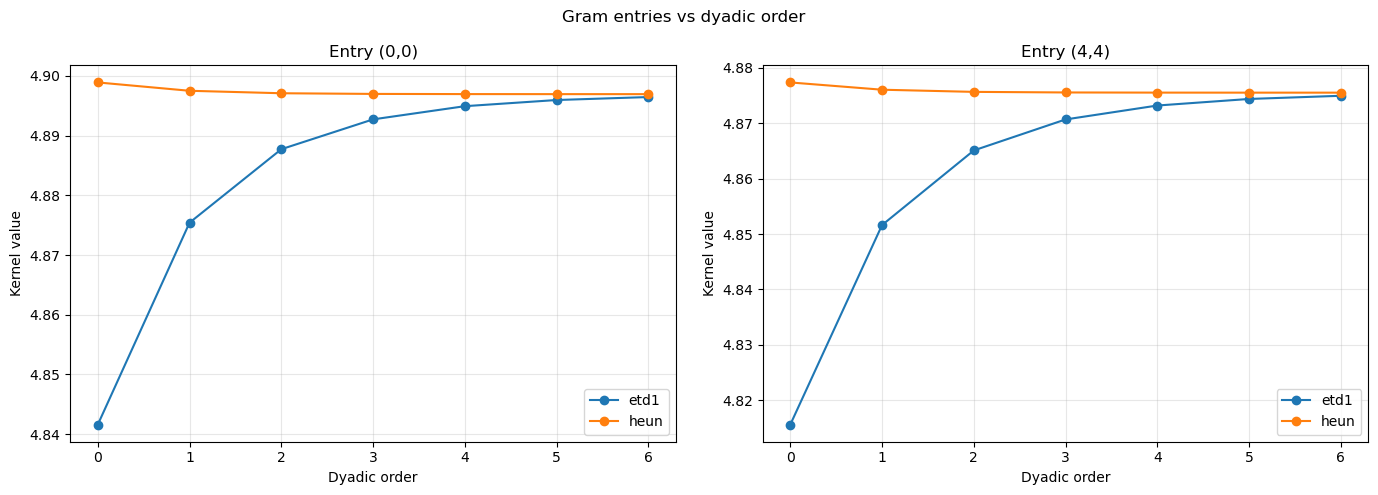

Target shape: (5, 5)


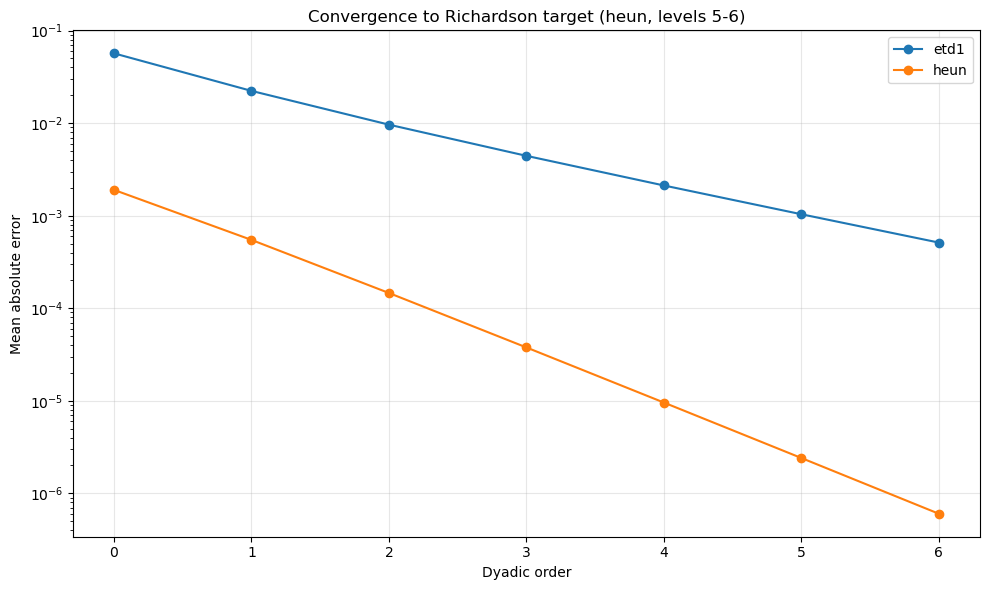

In [10]:
raw_results = run_sweep(max_dyadic_order=6)

# Richardson target: heun extrapolated from dyadic levels 5 and 6
heun_vals = np.stack(raw_results['heun'])      # (7, 5, 5)
fac = 2.0 ** RICHARDSON_ORDER['heun']
R1 = (fac * heun_vals[1:] - heun_vals[:-1]) / (fac - 1.0)
target = R1[-1]                                # extrapolated from levels 5 and 6

print('Target shape:', target.shape)
plot_errors(raw_results, target)